The **Llama-8B model** can need

#####  with fp-32:
- 32 GB for the model `parameters` (8B * 4 Bytes = 32 GB)
- 32 GB for the model `Gradients` (8B * 4 Bytes = 32 GB)
- 64 GB for the `optimizer  states` (8B *  2 * 4 Bytes) = 64 GB

`around 128 GB in total` This cannot fit on one GPU.

#####  with fp-16:
- 16 GB for the model `parameters` (8B * 2 Bytes = 16 GB)
- 16 GB for the model `Gradients` (8B * 2 Bytes = 16 GB)
- 32 GB for the `optimizer states`.(8B *  2 * 2 Bytes) = 32 GB

`around 64 GB in total`

Half-precision
Quantization
Gradient accumulation (many GPUs)


Llama takes three inputs:

- Tokens
- Attention mask
- Positional Embedding

Evaluation Metrics:
- Perplexity
- BLEU, ROUGE

##### Import Libraries

In [1]:
# ShoW each Cell's Execution Time
# %pip install ipython-autotime  datasets boto3 python-dotenv bitsandbytes
# %pip install --upgrade transformers
%load_ext autotime

time: 0 ns (started: 2024-08-19 09:33:36 +03:00)


In [2]:
import torch
if torch.cuda.is_available():
    DEVICE = torch.device('cuda:0')
    print(f" DEVICE: {DEVICE}. GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    DEVICE = 'cpu'
    print(f" DEVICE: {DEVICE}. No GPU available. Training will run on CPU.")

 DEVICE: cuda:0. GPU: NVIDIA GeForce RTX 4050 Laptop GPU is available.
time: 1.22 s (started: 2024-08-19 09:33:36 +03:00)


In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as F

from transformers import LlamaTokenizer, LlamaForCausalLM , AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline,  BertTokenizer, BertModel, get_linear_schedule_with_warmup,DataCollatorWithPadding
from torch.utils.data import DataLoader, Dataset, RandomSampler
from datasets import load_dataset
from torch.utils.data import Subset, Dataset

import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import re
import os
from functools import partial
import boto3

import warnings
import logging
import sys

import json
from dotenv import load_dotenv
load_dotenv()
HF_TOKEN = os.getenv('TF_TOKEN')

# from google.colab import userdata
# HF_TOKEN= userdata.get('HF_TOKEN')

time: 2.8 s (started: 2024-08-19 09:33:38 +03:00)


In [4]:
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub.file_download")

# Set the logging level for transformers to ERROR
logging.getLogger("transformers").setLevel(logging.ERROR)

# # Ignore specific warnings
# warnings.filterwarnings("ignore", message=".*beta.*")
# warnings.filterwarnings("ignore", message=".*gamma.*")

time: 0 ns (started: 2024-08-19 09:33:40 +03:00)


In [5]:
#for local vscode
sys.path.append('./src') #link to GTL libraries
import src.guided_transfer_learning as gtl
#
# #for kaggle:
# import sys
# sys.path.append('/kaggle/input/gtl-devtech/Guided Transfer Learning-DevTech/guided_transfer_learning_library/src') #link to GTL libraries
# import guided_transfer_learning as gtl

time: 15 ms (started: 2024-08-19 09:33:40 +03:00)


##### Functions:

In [6]:
plt.style.use('dark_background')

time: 0 ns (started: 2024-08-19 09:33:40 +03:00)


In [7]:
def download_from_s3(bucket_name, s3_file_path, local_file_path):
    s3 = boto3.client('s3')
    s3.download_file(bucket_name, s3_file_path, local_file_path)
    print(f'File s3://{bucket_name}/{s3_file_path} downloaded to {local_file_path}')

def upload_to_s3(local_file_path, bucket_name, s3_file_path):
    s3 = boto3.client('s3')
    s3.upload_file(local_file_path, bucket_name, s3_file_path)
    print(f'File {local_file_path} uploaded to s3://{bucket_name}/{s3_file_path}')


time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [8]:
def plot_multiple_results(results_list, title="Train and Validation Results (Accuracy and Loss)",legend_fontsize=9, nb_epochs_toplot=None):
    fig, axs = plt.subplots(1, 2, figsize=(40, 10))

    styles = [
        {'linestyle': (0,(1,1)), 'marker': 'o', 'color': '#2ca02c'},
        {'linestyle': 'dashdot', 'marker': 'x', 'color': '#1f77b4'},
        {'linestyle': (0,(5,1)), 'marker': 's', 'color': '#d62728'},
        {'linestyle': (5,(10,3)), 'marker': 'd', 'color': '#ff7f0e'}
    ]

    for i, results in enumerate(results_list):
        train_loss, train_acc = results['train_results']
        val_loss, val_acc = results['validation_results']


        if nb_epochs_toplot is None:
            max_epochs = max(max(len(train_acc) for results in results_list),
                        max(len(val_acc) for results in results_list),
                        max(len(train_loss) for results in results_list),
                        max(len(val_loss) for results in results_list))
        else:
            max_epochs = nb_epochs_toplot


        train_loss , train_acc , val_loss, val_acc = train_loss[:max_epochs], train_acc[:max_epochs], val_loss[:max_epochs+1], val_acc[:max_epochs+1],

        style = styles[i % len(styles)]

        # Plot the training and validation accuracy
        axs[0].plot(range(1,len(train_acc) + 1), train_acc, marker=style['marker'], markersize=3, color=style['color'], label=f'Training Accuracy Selection {i+1}')
        axs[0].plot(val_acc, linestyle=style['linestyle'], marker=style['marker'],  markersize=3, color=style['color'], label=f'Validation Accuracy Selection {i+1}')

        # Plot the training and validation loss
        axs[1].plot(range(1,len(train_loss) + 1), train_loss, marker=style['marker'], markersize=3,color=style['color'], label=f'Training Loss Selection {i+1}')
        axs[1].plot(val_loss, linestyle=style['linestyle'], marker=style['marker'], markersize=3,color=style['color'], label=f'Validation Loss Selection {i+1}')

        # Set x-axis ticks to integers


    for ax in axs:
        ax.set_xticks(range(0, max_epochs + 1, 2))

    # Set labels and titles
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_title('Training and Validation Accuracy')
    axs[0].legend(fontsize=legend_fontsize)

    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].legend(fontsize=legend_fontsize)

    # Add a title to the figure
    fig.suptitle(title)

    # Show the plot
    plt.show()


time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [9]:
# Iterate over all parameters in the model
def check_trainable_layers(model):
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name} is || TRAINABLE || ")
        else:
            print(f"{name} is || NOT TRAINABLE || ")
# Iterate over all parameters in the model

def list_model_layers(model):
    for name, param in model.named_parameters():
        print(f"{name}")

time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [10]:
def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

def unfreeze_BERT_layers(bert, nb_layer_to_unfreeze):
    if (0 < nb_layer_to_unfreeze <= len(bert.encoder.layer)):
        # Unfreeze the last 'nb_layer_to_unfreeze' layers
        for layer in bert.encoder.layer[-nb_layer_to_unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True
        # Freeze the remaining layers
        for layer in bert.encoder.layer[:len(bert.encoder.layer) - nb_layer_to_unfreeze]:
            for param in layer.parameters():
                param.requires_grad = False
    else:
        print(" Number of unfreeze layers is larger than number of layers or less than 1.")

time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [11]:

# Define the plotting function
def plot_loss(numbers):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(numbers) + 1), numbers, marker='o', linestyle='-')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss (Epochs)')
    plt.grid(True)
    plt.show()

def plot_acc_loss(results):
    # Create a figure and axis objects for the loss and accuracy plots
    fig, axs = plt.subplots(1,2, figsize=(16, 4))

    # Plot the loss values
    axs[0].plot(results[0], label='Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training Loss')

    # Plot the accuracy values
    axs[1].plot(results[1], label='Accuracy', color='orange')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].set_title('Training Accuracy')

    # Show the plots
    plt.show()

time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [12]:
# Iterate over all parameters in the model
def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [13]:
# Define the plotting function
def plot_loss(numbers):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(numbers) + 1), numbers, marker='o', linestyle='-')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss (Epochs)')
    plt.grid(True)
    plt.show()

def plot_acc_loss(results):
    # Create a figure and axis objects for the loss and accuracy plots
    fig, axs = plt.subplots(1,2, figsize=(16, 4))

    # Plot the loss values
    axs[0].plot(results[0], label='Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training Loss')

    # Plot the accuracy values
    axs[1].plot(results[1], label='Accuracy', color='orange')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].set_title('Training Accuracy')

    # Show the plots
    plt.show()


time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [133]:

def plot_results(results, title="Train and Validation Results (Accuracy and Loss)"):
    # Unpack the results
    train_loss = results['train_results']
    val_loss = results['validation_results']

    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 2, figsize=(20, 6))
    # Plot the training and validation loss
    axs[1].plot(range(1,len(train_loss)+1),train_loss, label='Training Loss')
    axs[1].plot(val_loss, label='Validation Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].legend()

    # Add a title to the figure
    fig.suptitle(title)

    # Show the plot
    plt.show()


time: 0 ns (started: 2024-08-19 11:33:30 +03:00)


In [15]:

def add_selection_range(dataset_indexes_selection, previous_selections, goemotions_train_dataset_B, random_classes_B, limit_per_class):
    # Iterate over each class in the list of random classes
    for class_ in random_classes_B:
        class_indexes = []  # Initialize a list to store indexes of items belonging to the current class
        # Iterate over the dataset to find items that match the current class
        for i, item in enumerate(goemotions_train_dataset_B):
            if item['labels'] == [class_] and i not in previous_selections:
                class_indexes.append(i)  # Add the index to the class_indexes list
            # If the number of items for the current class reaches the limit, stop the search for this class
            if len(class_indexes) == limit_per_class:
                break
        # Extend the main selection list with the indexes found for the current class
        dataset_indexes_selection.extend(class_indexes)
    # Extend the previous selections list with the new selections
    previous_selections.extend(dataset_indexes_selection)


time: 16 ms (started: 2024-08-19 09:33:41 +03:00)


In [16]:

def unfreeze_BERT_layers(bert, nb_layer_to_unfreeze):
    if (0 < nb_layer_to_unfreeze <= len(bert.encoder.layer)):
        # Unfreeze the last 'nb_layer_to_unfreeze' layers
        for layer in bert.encoder.layer[-nb_layer_to_unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True
        # Freeze the remaining layers
        for layer in bert.encoder.layer[:len(bert.encoder.layer) - nb_layer_to_unfreeze]:
            for param in layer.parameters():
                param.requires_grad = False
    else:
        print(" Number of unfreeze layers is larger than number of layers or less than 1.")

time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


In [17]:
def rescale_matrix_layer_by_layer(matrix):
    for layer in matrix:
        min_layer = torch.amin(matrix[layer])
        max_layer = torch.amax(matrix[layer])
        scale =  1/(max_layer - min_layer)
        if scale is not torch.inf:
            matrix[layer] = scale *  matrix[layer]

time: 0 ns (started: 2024-08-19 09:33:41 +03:00)


##### Simple Llama from Scratch

In [112]:
import torch
import torch.nn as nn

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            # nn.ReLU(),
            # nn.Linear(ff_hidden_dim, embed_dim)
        )
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Attention
        attn_output, _ = self.attention(x, x, x)
        x = self.layer_norm1(x + attn_output)
        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.layer_norm2(x + ff_output)
        return x

class SimpleLlama(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim,pad_token_id=0):
        super(SimpleLlama, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_hidden_dim) for _ in range(num_layers)
        ]) 
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self.embed_dim = embed_dim
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Embedding
        x = self.embedding(input_ids)
        x = x.transpose(0, 1)  # Sequence-first for PyTorch Transformer
        
        # Attention mask handling
        if attention_mask is not None:
            # Convert attention mask to the format expected by PyTorch Transformer
            # PyTorch's MultiheadAttention expects a mask of shape (target_seq_len, source_seq_len)
            attention_mask = attention_mask.unsqueeze(1).expand(-1, input_ids.size(1), -1)  # Shape (batch_size, seq_len, seq_len)
            attention_mask = attention_mask.unsqueeze(1).repeat(1, self.embed_dim, 1, 1)  # Shape (batch_size, embed_dim, seq_len, seq_len)
            attention_mask = attention_mask.float().masked_fill(attention_mask == 0, float('-inf')).masked_fill(attention_mask == 1, float(0.0))

        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        x = x.transpose(0, 1)  # Batch-first

        # Output logits
        logits = self.fc_out(x)
        
        outputs = {"logits": logits}
        
        if labels is None:
            outputs['loss'] = None
        else:
            # Compute loss if labels are provided
            B,T,C = logits.shape
            # print('B:', B) 
            # print('T:', T) 
            # print('C:', C) 

            # print('logits.size(-1): ', logits.size(-1))
            # print('labels.view(-1): ', labels.view(-1))
            
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
            outputs["loss"] = loss
        
        return outputs
    

    def generate(self,input_ids, max_length, temperature=1.0):
        self.eval()  # Set the model to evaluation mode
        
        with torch.no_grad():
            for _ in range(max_length - len(input_ids)):
                # Forward pass
                outputs = self(input_ids)
                next_token_logits = outputs["logits"][:, -1, :]
                
                # Apply temperature
                next_token_logits = next_token_logits / temperature
                
                # Sample from the filtered distribution
                probs = F.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                
                # Append the new token to the input sequence
                input_ids = torch.cat([input_ids, next_token], dim=-1)
                
                # Check if we've generated an end-of-sequence token
                if next_token.item() == '<|end_of_sentence|>':
                    break
        
        return input_ids


time: 0 ns (started: 2024-08-19 10:21:52 +03:00)


In [19]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"

llama_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama_tokenizer.pad_token = llama_tokenizer.eos_token


time: 985 ms (started: 2024-08-19 09:33:44 +03:00)


In [84]:
# Sample sentence
sentence = "This is a test sentence for LLaMA."

# Tokenize the input sentence
tokenized_input = llama_tokenizer(sentence, return_tensors='pt')
print(tokenized_input)


# Extract input_ids and attention_mask
input_ids = tokenized_input['input_ids'].to(DEVICE)
attention_mask = tokenized_input['attention_mask'].to(DEVICE)
print(input_ids)
print(attention_mask)

{'input_ids': tensor([[128000,   2028,    374,    264,   1296,  11914,    369,    445,   8921,
           4940,     13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
tensor([[128000,   2028,    374,    264,   1296,  11914,    369,    445,   8921,
           4940,     13]], device='cuda:0')
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')
time: 0 ns (started: 2024-08-19 10:06:37 +03:00)


In [91]:
# Tokenize the input sentence
tokenized_input = llama_tokenizer(sentence, max_length=8, padding='max_length', truncation=True, return_tensors='pt')
print(tokenized_input)

{'input_ids': tensor([[128000,   2028,    374,    264,   1296,  11914,    369,    445]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}
time: 0 ns (started: 2024-08-19 10:10:10 +03:00)


In [92]:
print(llama_tokenizer.vocab_size)
print(len(llama_tokenizer))

128000
128256
time: 16 ms (started: 2024-08-19 10:10:20 +03:00)


In [113]:
# Example usage
vocab_size = len(llama_tokenizer)     #Real   Llama values # Example vocabulary size
embed_dim = 1         #4096   #Real Llama values  # Example embedding dimension
num_heads = 1           #64     # Number of attention heads
num_layers = 1          #60     # Number of transformer layers
ff_hidden_dim = 1     #4096   # Feed-forward hidden dimension

simple_llama_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)


time: 47 ms (started: 2024-08-19 10:22:04 +03:00)


In [114]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
with autocast():
    outputs = simple_llama_model(input_ids, attention_mask=attention_mask, labels=input_ids)


time: 0 ns (started: 2024-08-19 10:22:07 +03:00)


In [115]:
output_tokens = simple_llama_model.generate(input_ids, max_length=32)
llama_tokenizer.decode(output_tokens[0]) 

'<|begin_of_text|>This is a test sentence for LLaMA._FEcamp destacullyﺪapos.HE++];\n dx_shaThrown hete\',� bởiAsyncResult探AdjustedWG lịch 【HomeAs875.onOptionsItemSelected狐(@" ((( paramIntyield Turk.SEVER'

time: 360 ms (started: 2024-08-19 10:22:10 +03:00)


In [116]:
print(outputs['logits']); print(outputs['loss']) ; 
print(outputs['logits'].shape)

tensor([[[ 0.1605,  0.0373,  0.4031,  ..., -0.2399,  0.4927,  0.2489],
         [ 0.1605,  0.0373,  0.4031,  ..., -0.2399,  0.4927,  0.2489],
         [ 0.1605,  0.0373,  0.4031,  ..., -0.2399,  0.4927,  0.2489],
         ...,
         [ 0.1605,  0.0373,  0.4031,  ..., -0.2399,  0.4927,  0.2489],
         [ 0.1605,  0.0373,  0.4031,  ..., -0.2399,  0.4927,  0.2489],
         [ 0.1605,  0.0373,  0.4031,  ..., -0.2399,  0.4927,  0.2489]]],
       device='cuda:0', dtype=torch.float16, grad_fn=<ViewBackward0>)
tensor(12.0405, device='cuda:0', grad_fn=<NllLossBackward0>)
torch.Size([1, 11, 128256])
time: 63 ms (started: 2024-08-19 10:22:15 +03:00)


In [70]:
# Total number of parameters
total_params = sum(p.numel() for p in simple_llama_model.parameters())
print(f"Total number of parameters: {total_params}")

Total number of parameters: 384782
time: 0 ns (started: 2024-08-19 09:57:57 +03:00)


In [71]:
# Sample sentence
sentence = "This is a test sentence for LLaMA."
tokenized_input = llama_tokenizer(sentence, return_tensors='pt')

input_ids = tokenized_input['input_ids'].to(DEVICE)
attention_mask = tokenized_input['attention_mask'].to(DEVICE)
with autocast():
    outputs = simple_llama_model(input_ids, attention_mask=attention_mask, labels=input_ids)

probabilities = torch.nn.functional.softmax(outputs['logits'], dim=-1)
predicted_token_ids = torch.argmax(probabilities, dim=-1)
sentences = llama_tokenizer.batch_decode(predicted_token_ids, skip_special_tokens=True)
print(sentences)

B: 1
T: 11
C: 128256
logits.size(-1):  128256
labels.view(-1):  tensor([128000,   2028,    374,    264,   1296,  11914,    369,    445,   8921,
          4940,     13], device='cuda:0')
['asasasasasasasasasasas']
time: 31 ms (started: 2024-08-19 09:58:04 +03:00)


##### Dataset

In [72]:
# Load and tokenize the dataset
wikitext_dataset = load_dataset("wikitext", "wikitext-103-raw-v1")

time: 14 s (started: 2024-08-19 09:58:06 +03:00)


In [73]:
wikitext_dataset

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

time: 16 ms (started: 2024-08-19 09:58:20 +03:00)


In [96]:
#Only keep the texts that are not empty
wikitext_train_dataset = wikitext_dataset['train'].filter(lambda x: len(x['text']) != 0 )
wikitext_val_dataset = wikitext_dataset['validation'].filter(lambda x: len(x['text']) != 0 )
wikitext_test_dataset = wikitext_dataset['test'].filter(lambda x:  len(x['text']) != 0 )


time: 62 ms (started: 2024-08-19 10:12:46 +03:00)


In [97]:
# Number of samples to take
num_samples = 100

# Subset the dataset
train_subset = wikitext_train_dataset.select(range(num_samples))
val_subset = wikitext_val_dataset.select(range(num_samples))
test_subset = wikitext_test_dataset.select(range(num_samples))


time: 0 ns (started: 2024-08-19 10:12:48 +03:00)


In [95]:
# Tokenize Datasets:
def tokenize_function(examples):
    # return llama_tokenizer(example["text"],truncation=True,padding=True,max_length=llama_tokenizer.model_max_length,return_tensors='pt')
    return llama_tokenizer(examples["text"], truncation=True, padding="max_length", return_tensors="pt")



def tokenize_function_lenght_4(examples):
    # return llama_tokenizer(example["text"],truncation=True,padding=True,max_length=llama_tokenizer.model_max_length,return_tensors='pt')
    return llama_tokenizer(examples["text"], max_length=4, truncation=True, padding="max_length", return_tensors="pt")

time: 0 ns (started: 2024-08-19 10:12:20 +03:00)


In [44]:
print(llama_tokenizer.decode([128000]))
print(llama_tokenizer.decode([128001]))
print(llama_tokenizer.decode([128002]))
print(llama_tokenizer.decode([128003]))
print(llama_tokenizer.decode([128004]))
print(llama_tokenizer.decode([128005]))
print(llama_tokenizer.decode([128006]))
print(llama_tokenizer.decode([128007]))
print(llama_tokenizer.decode([128008]))
print(llama_tokenizer.decode([128009]))

<|begin_of_text|>
<|end_of_text|>
<|reserved_special_token_0|>
<|reserved_special_token_1|>
<|finetune_right_pad_id|>
<|reserved_special_token_2|>
<|start_header_id|>
<|end_header_id|>
<|eom_id|>
<|eot_id|>
time: 0 ns (started: 2024-08-19 09:44:37 +03:00)


In [98]:
# Tokenize each subset
train_tokenized = train_subset.map(tokenize_function_lenght_4, batched=True, remove_columns=["text"])
val_tokenized = val_subset.map(tokenize_function_lenght_4, batched=True, remove_columns=["text"])
test_tokenized = test_subset.map(tokenize_function_lenght_4, batched=True, remove_columns=["text"])


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

time: 391 ms (started: 2024-08-19 10:12:53 +03:00)


In [45]:
# print(train_tokenized[0])

time: 0 ns (started: 2024-08-19 09:45:25 +03:00)


In [99]:

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, tokenized_data):
        self.input_ids = tokenized_data["input_ids"]
        self.attention_mask = tokenized_data["attention_mask"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
        }
        return item

# Convert tokenized data to PyTorch Datasets
train_dataset = CustomDataset(train_tokenized)
val_dataset = CustomDataset(val_tokenized)
test_dataset = CustomDataset(test_tokenized)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=2)
test_dataloader = DataLoader(test_dataset, batch_size=2)


time: 140 ms (started: 2024-08-19 10:12:58 +03:00)


In [100]:
for batch in train_dataloader:
    print(type(batch))
    print(batch)
    break

<class 'dict'>
{'input_ids': tensor([[128000,  34701,  50657,  14333],
        [128000,    386,  10336,     22]]), 'attention_mask': tensor([[1, 1, 1, 1],
        [1, 1, 1, 1]])}
time: 0 ns (started: 2024-08-19 10:13:01 +03:00)


##### Train and Evaluate Functions

time: 16 ms (started: 2024-08-19 11:52:02 +03:00)


##### Train 

In [139]:
# Empty GPU cache
torch.cuda.empty_cache()

time: 16 ms (started: 2024-08-19 11:52:05 +03:00)


In [120]:
epochs = 8 
lr_train_classifier = 5e-5
optimizer=AdamW(simple_llama_model.parameters(),lr=lr_train_classifier)
llama_3_losses = train_model(simple_llama_model,
                             optimizer=AdamW(simple_llama_model.parameters(),lr=lr_train_classifier),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True)

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 12.14 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: 12.13 || Validation loss: 12.14
# Epoch: 2 (Learning rate: 4.375e-05)  Training loss: 12.13 || Validation loss: 12.14
# Epoch: 3 (Learning rate: 3.7500000000000003e-05)  Training loss: 12.12 || Validation loss: 12.14
# Epoch: 4 (Learning rate: 3.125e-05)  Training loss: 12.12 || Validation loss: 12.14
# Epoch: 5 (Learning rate: 2.5e-05)  Training loss: 12.12 || Validation loss: 12.14
# Epoch: 6 (Learning rate: 1.8750000000000002e-05)  Training loss: 12.12 || Validation loss: 12.14
# Epoch: 7 (Learning rate: 1.25e-05)  Training loss: 12.12 || Validation loss: 12.14
# Epoch: 8 (Learning rate: 6.25e-06)  Training loss: 12.12 || Validation loss: 12.14
time: 2min 3s (started: 2024-08-19 10:31:42 +03:00)


##### Create Reference Model

In [126]:
# Example usage
vocab_size = len(llama_tokenizer)     #Real   Llama values # Example vocabulary size
embed_dim = 2         #4096   #Real Llama values  # Example embedding dimension
num_heads = 1           #64     # Number of attention heads
num_layers = 1          #60     # Number of transformer layers
ff_hidden_dim = 2     #4096   # Feed-forward hidden dimension

llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)

time: 46 ms (started: 2024-08-19 10:51:58 +03:00)


In [127]:
# UNFREEEZE ALL LAYERS 


time: 0 ns (started: 2024-08-19 10:51:59 +03:00)


In [128]:
# # Save the model's state dictionary
torch.save(llama3_model.state_dict(), 'C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/simple_llama_model_reference.pt')

time: 32 ms (started: 2024-08-19 10:52:05 +03:00)


In [129]:
llama3_model.load_state_dict(torch.load('C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/simple_llama_model_reference.pt'))

<All keys matched successfully>

time: 16 ms (started: 2024-08-19 10:52:06 +03:00)


##### Create Scouts and Guidance Matrix

In [131]:
llama3_scouts = gtl.create_scouts(llama3_model, should_save_guidance=True, should_save_scouts=False, use_squared_differences=True)
print("Scouts created")

Scouts created
time: 16 ms (started: 2024-08-19 11:23:55 +03:00)


In [154]:
# Define the training function
def train_model(model, optimizer, epochs, train_loader, validation_loader, with_early_stopping=True, train_loader_sampler=None, validation_loader_sampler=None, train_verbose=True, eval_verbose=True, with_GTL=False, guidance_matrix=None, patience=3, time_to_sleep=15):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    skip = 2000 if epochs > 10000 else 300 if epochs > 1000 else 30 if epochs > 100 else 5 if epochs > 10 else 1
    model.train()
    train_loss_vals = [];  val_loss_vals = [];

    num_training_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

    scaler = torch.cuda.amp.GradScaler()

    print(f"# Epoch: 0  (Before start training) ")
    val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=eval_verbose)
    val_loss_vals.append(val_loss)
    print("================================================================================================")
    for epoch in range(epochs):
        epoch_loss = 0.0; epoch_loss_sum = 0.0; 
        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f"# Epoch: {epoch+1} (Learning rate: {optimizer.param_groups[0]['lr']}) ", end='')
            
        for batch in tqdm(train_loader):
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            # Use autocast for mixed precision training
            with torch.autocast(device_type="cuda"):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']

            model.zero_grad()
            # Scale the loss for gradient calculation
            scaler.scale(loss).backward()
            if with_GTL and guidance_matrix is None:
                print('Guidance matrix is not provided')
                return None
            if with_GTL and guidance_matrix is not None:
                gtl.apply_guidance(model, guidance_matrix)
            scaler.step(optimizer)

            # Update the scale for next iteration
            scaler.update()
            # Update the learning rate
            scheduler.step()

            epoch_loss_sum += loss.item()
        epoch_loss = epoch_loss_sum / len(train_loader)
        train_loss_vals.append(epoch_loss)
        val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=False)
        val_loss_vals.append(val_loss)

        if with_early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement == patience:
                    print(f'Early stopping after {epochs_without_improvement+1} epochs without improvement.')
                    print(f'- Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f} \n ')
                    break

        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f' Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f}')
        time.sleep(time_to_sleep)
    return {'train_results': [train_loss_vals], 'validation_results': [val_loss_vals],}

# Define the evaluation function
def evaluate_model(model, loader, loader_sampler=None, verbose=True, dataset_category="Validation"):
    model.eval() 
    total_loss = 0; total_acc = 0 ;
    if verbose:
        print(f"# Evaluating on {dataset_category} Dateset: ", end= '')
    with torch.no_grad():
        for batch in tqdm(loader):
        # for batch in loader:
            input_ids = batch['input_ids'].to(device=DEVICE)
            attention_mask = batch['attention_mask'].to(device=DEVICE) # mask for attention

            # Use autocast for mixed precision evaluation
            with torch.autocast(device_type="cuda"):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']  # The loss is directly provided by the model
                
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if verbose:
        print(f'# {dataset_category} loss: {avg_loss:.2f} ')
    return avg_loss

# time.sleep(1000)

time: 0 ns (started: 2024-08-19 12:20:17 +03:00)


In [155]:
def plot_results(results, title="Train and Validation Loss"):
    # Unpack the results
    train_loss = results['train_results'][0]
    val_loss = results['validation_results'][0]

    # Create a figure
    fig, axs = plt.subplots(figsize=(12, 6))

    # Plot the training and validation loss
    axs.plot(range(1,len(train_loss)+1),train_loss, label='Training Loss')
    axs.plot(val_loss, label='Validation Loss')
    axs.set_xlabel('Epoch')
    axs.set_ylabel('Loss')
    axs.set_title(title)
    axs.legend()

    # Show the plot
    plt.show()


time: 0 ns (started: 2024-08-19 12:20:20 +03:00)


Start training :

Scout nb 1/2 Training Start:
# Llama-3 Reference Model loaded. Starting training model with 1 layer(s) unfrozen.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: 

100%|██████████| 25/25 [00:00<00:00, 80.99it/s]


# Validation loss: 12.11 
# Epoch: 1 (Learning rate: 2e-05) 

100%|██████████| 25/25 [00:00<00:00, 806.50it/s]


 Training loss: 12.08 || Validation loss: 12.11
# Epoch: 2 (Learning rate: 1e-05) 

100%|██████████| 25/25 [00:00<00:00, 822.87it/s]

 Training loss: 12.08 || Validation loss: 12.11


{'train_results': [[12.0848828125, 12.084765625]], 'validation_results': [[12.1140234375, 12.11337890625, 12.11349609375]]}


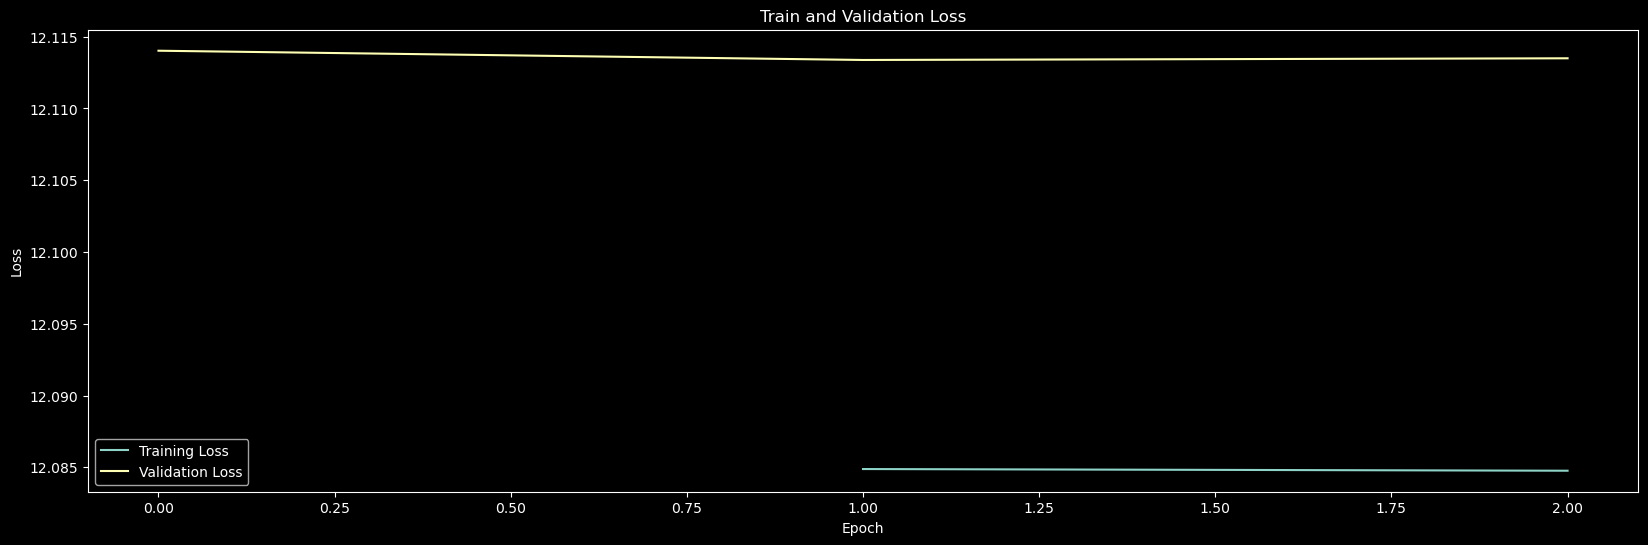

# Evaluating on Test Dateset: 

100%|██████████| 25/25 [00:00<00:00, 591.09it/s]

# Test loss: 12.54 

# Scout nb 1/2 Training End.

Scout nb 2/2 Training Start:


# Llama-3 Reference Model loaded. Starting training model with 1 layer(s) unfrozen.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: 

100%|██████████| 25/25 [00:00<00:00, 876.25it/s]


...

100%|██████████| 25/25 [00:00<00:00, 925.44it/s]

 Training loss: 12.08 || Validation loss: 12.11


# Epoch: 2 (Learning rate: 1e-05) 

100%|██████████| 25/25 [00:00<00:00, 781.30it/s]


 Training loss: 12.08 || Validation loss: 12.11
{'train_results': [[12.0844921875, 12.08431640625]], 'validation_results': [[12.11349609375, 12.11333984375, 12.1132421875]]}


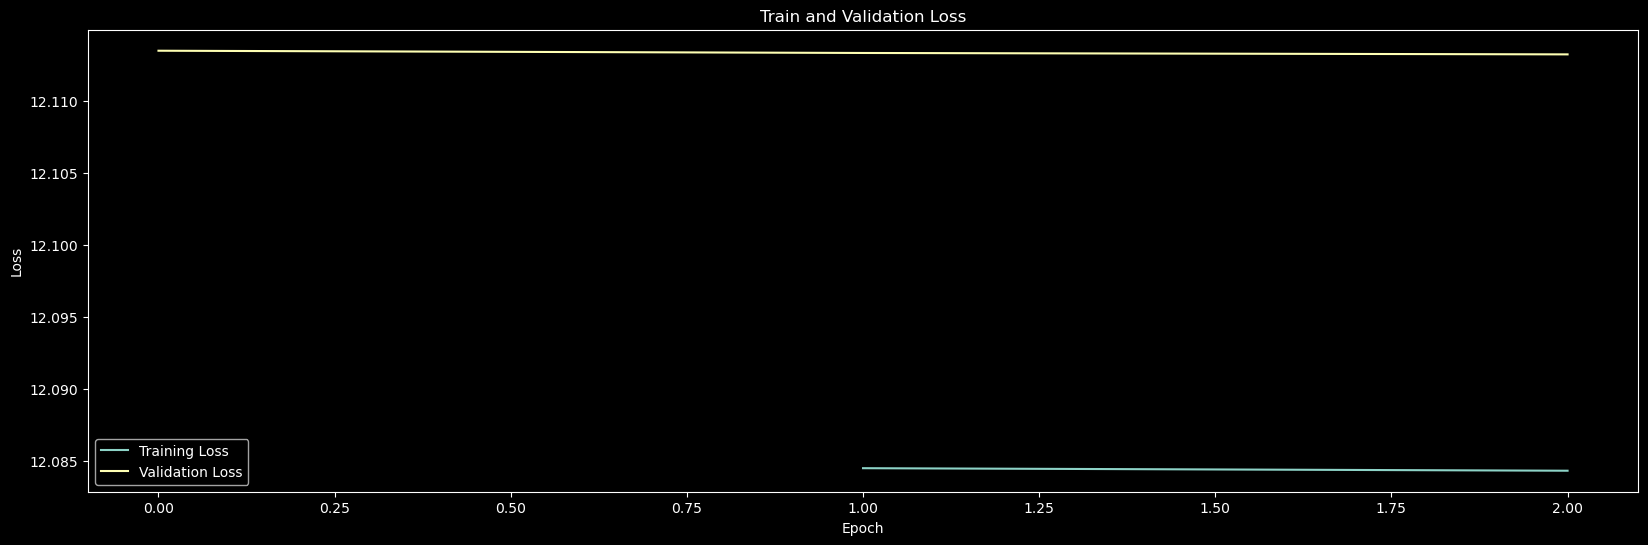

# Evaluating on Test Dateset: 

100%|██████████| 25/25 [00:00<00:00, 111.17it/s]

# Test loss: 12.54 

# Scout nb 2/2 Training End.

All Scouts Training End.

time: 1min 39s (started: 2024-08-19 12:20:20 +03:00)


In [156]:
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
nb_scouts =  2
epochs = 2 
patience  = 2 
batch_size = 4 
loss_function = nn.CrossEntropyLoss()  #combines the softmax activation function and the negative log-likelihood loss in a single operation
nb_of_layers_to_unfreeze = 1
dropout = 0.5
learning_rate = 2e-5

print("Start training :\n")
for i in range(nb_scouts): 
    print(f"=============================================================\nScout nb {i+1}/{nb_scouts} Training Start:") 

    # First one scout => One dataset from the pile

    wikitext_dataset = load_dataset("wikitext", "wikitext-103-raw-v1")

    wikitext_train_dataset = wikitext_dataset['train'].filter(lambda x: len(x['text']) != 0 )
    wikitext_val_dataset = wikitext_dataset['validation'].filter(lambda x: len(x['text']) != 0 )
    wikitext_test_dataset = wikitext_dataset['test'].filter(lambda x:  len(x['text']) != 0 )

    num_samples = 100

    # Subset the dataset
    train_subset = wikitext_train_dataset.select(range(num_samples))
    val_subset = wikitext_val_dataset.select(range(num_samples))
    test_subset = wikitext_test_dataset.select(range(num_samples))

    # Tokenize each subset
    train_tokenized = train_subset.map(tokenize_function_lenght_4, batched=True, remove_columns=["text"])
    val_tokenized = val_subset.map(tokenize_function_lenght_4, batched=True, remove_columns=["text"])
    test_tokenized = test_subset.map(tokenize_function_lenght_4, batched=True, remove_columns=["text"])

    # Convert tokenized data to PyTorch Datasets
    train_dataset = CustomDataset(train_tokenized)
    val_dataset = CustomDataset(val_tokenized)
    test_dataset = CustomDataset(test_tokenized)

    # Create DataLoaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)    
    
    # Load reference model:
    llama3_model.load_state_dict(torch.load('C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/simple_llama_model_reference.pt'))

    print(f"# Llama-3 Reference Model loaded. Starting training model with {nb_of_layers_to_unfreeze} layer(s) unfrozen.") 

    
    # train model (not intersted in results: _)
    optimizer=AdamW(simple_llama_model.parameters(),lr=lr_train_classifier)
    print('================================================================')
    llama_3_losses = train_model(simple_llama_model,
                                 optimizer=AdamW(simple_llama_model.parameters(),lr=learning_rate),
                                 epochs=epochs,
                                 train_loader=train_dataloader,
                                 validation_loader=val_dataloader,
                                 patience=patience,
                                 train_verbose=True, 
                                 eval_verbose=True)
    print(llama_3_losses)
    plot_results(llama_3_losses)

    _ = evaluate_model(llama3_model,test_dataloader,dataset_category="Test") 

    print(f"\n# Scout nb {i+1}/{nb_scouts} Training End.\n=============================================================\n")
    llama3_scouts.add_scout(llama3_model) 
print("All Scouts Training End.\n=============================================================\n")



In [136]:
#create the guidance matrix from the scouts:

llama3_raw_guidance_matrix = llama3_scouts.create_raw_guidance(DEVICE)

time: 0 ns (started: 2024-08-19 11:41:45 +03:00)


In [ ]:
gtl.save_guidance_matrix(llama3_raw_guidance_matrix, name='llama3_raw_guidance_matrix.pt') 

In [ ]:
gtl.plot_guidance_distribution(llama3_raw_guidance_matrix)

In [ ]:
llama3_sub_layers_list = ['',
                          'self_attn',
                          'self_attn.q_proj',
                          'self_attn.k_proj',
                          'self_attn.v_proj',
                          'self_attn.o_proj',
                          'self_attn.rotary_emb',
                          'mlp',
                          'mlp.gate_proj',
                          'mlp.up_proj',
                          'mlp.down_proj',
                          'mlp.act_fn',
                          'input_layernorm',
                          'post_attention_layernorm'
                          ] 

In [ ]:
for layer_num in range(32):
    for sub_layer in llama3_sub_layers_list:
        gtl.plot_guidance_distribution(llama3_raw_guidance_matrix, name=f'model.layers.{layer_num}.{sub_layer}')
        print(f'bert.encoder.layer.{layer_num}.{sub_layer}')

##### Train With GTL

In [ ]:
#for vscode:
llama3_raw_guidance_matrix = gtl.load_guidance_matrix(name='llama3_raw_guidance_matrix.pt')

##### Train Without GTL

##### LLama from HF (with Quantization)

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", #4bit Normal Float
    bnb_4bit_compute_dtype=torch.bfloat16,
)

In [ ]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama_tokenizer.pad_token = llama_tokenizer.eos_token

In [ ]:
llama3_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", quantization_config=bnb_config, token=HF_TOKEN)

In [ ]:
llama_tokenizer("To open a colab notebook you need to ")

In [ ]:
test_text = "Hello this is a text to complete with"
tokenized_text = llama_tokenizer(test_text, return_tensors="pt")
print(tokenized_text)

In [ ]:
completion = llama3_model(tokenized_text['input_ids'],
                          tokenized_text['attention_mask'],
                          )

### Testing the Convergence of the model (28 classes):
If the model does not converge, the calculation of the Guidance matrix will not make sense.


#### Train only classifier with all layers frozen

#### Train Classifier with BERT frozen (Unfreeze two layers):

In [ ]:
epochs_train_classifier = 4
lr_train_classifier = 1e-4

bert = BertModel.from_pretrained('bert-base-uncased') # BERT frozen
print("- BERT downloaded.")
ClassificationBERT_ = ClassificationBERT(bert, num_labels=num_labels,dropout=0.5).to(DEVICE)
# Freeze all, train classifier only
print("- Starting training model with BERT frozen.\n")

criterion = nn.CrossEntropyLoss()  #combines the softmax activation function and the negative log-likelihood loss in a single operation

goemotions_train_losses_classifier = train_model(ClassificationBERT_,
                                                 optimizer=AdamW(ClassificationBERT_.parameters(),lr=lr_train_classifier),
                                                 criterion= nn.CrossEntropyLoss(),
                                                 epochs=epochs_train_classifier,
                                                 train_loader=goemotions_train_loader,
                                                 validation_loader=goemotions_val_loader,
                                                 train_loader_sampler=train_random_sampler,
                                                 validation_loader_sampler=val_random_sampler,
                                                 patience=2,
                                                 verbose=True)

print("- Classifier training with BERT frozen is finished.\n")

In [ ]:
plot_results(goemotions_train_losses_classifier)

#### Unfreeze some layers and Fine-tune

In [ ]:
nb_of_layers_to_unfreeze = 2  # number of layers to unfreeze in the BERT model
lr_fine_tuning = 1e-5
epochs_fine_tuning = 20

# Unfreeze certain layers and train encoder layers
unfreeze_BERT_layers(bert, nb_of_layers_to_unfreeze)
print(f"- Starting training model with {nb_of_layers_to_unfreeze} layers unfrozen.\n")
goemotions_train_losses_fine_tune = train_model(ClassificationBERT_,
                                                AdamW(ClassificationBERT_.parameters(),lr=lr_fine_tuning),
                                                criterion,
                                                epochs=epochs_fine_tuning,
                                                train_loader=goemotions_train_loader,
                                                validation_loader=goemotions_val_loader,
                                                train_loader_sampler=train_random_sampler,
                                                validation_loader_sampler=val_random_sampler,
                                                verbose=True,
                                                patience=2)
print("- BERT Fine-tuning finished.\n")

In [ ]:
plot_results(goemotions_train_losses_fine_tune)

In [ ]:
test_resutls = evaluate_model(ClassificationBERT_,
                              goemotions_test_loader,
                              criterion=criterion,
                              loader_sampler=test_random_sampler,
                              versbose=True)

### Create Reference Model: classifier should not be trained at all

In [ ]:
num_labels = 10  # number of labels in the datasetclass_indices = list(range(28))

bert_reference = BertModel.from_pretrained('bert-base-uncased') # BERT frozen
print("- BERT downloaded.")
ClassificationBERT_reference = ClassificationBERT(bert, num_labels=num_labels, dropout=0.5).to(DEVICE)
nb_of_layers_to_unfreeze = 1  # number of layers to unfreeze in the BERT model
print(f"{nb_of_layers_to_unfreeze} layer(s) from BERT unfrozen")
unfreeze_BERT_layers(bert_reference, nb_of_layers_to_unfreeze)

- Save reference model (once) to load each time

In [ ]:
# # Save the model's state dictionary
# torch.save(ClassificationBERT_reference.state_dict(), 'C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/ClassificationBERT_reference.pt')

- Load model

In [ ]:
ClassificationBERT_reference.load_state_dict(torch.load('C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/ClassificationBERT_reference.pt'))

### Create scouts

In [ ]:
my_scouts = gtl.create_scouts(ClassificationBERT_reference, should_save_guidance=True, should_save_scouts=False, use_squared_differences=True)
print("Scouts created")

- Choose random classes to create Dataset A (18 classes) and Dataset B (10 classes)

In [ ]:
# choose random classes for datasets A and B: A 18 classes and B 10 classes
random_classes_A = random.sample(range(0,27), 18); random_classes_A.sort();
random_classes_B = [ i for i in range(28) if i not in random_classes_A]; random_classes_A.sort();

print('Random classes for Dataset A: ', random_classes_A)
print('Random classes for Dataset B: ', random_classes_B)

In [ ]:
random_classes_A =  [1, 2, 3, 5, 6, 7, 9, 11, 12, 14, 15, 16, 17, 19, 20, 21, 24, 26]
random_classes_B = [0, 4, 8, 10, 13, 18, 22, 23, 25, 27]

### Train Scouts:

In [ ]:
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
nb_scouts =  10
epochs = 5
patience  = 2
batch_size = 128
loss_function = nn.CrossEntropyLoss()  #combines the softmax activation function and the negative log-likelihood loss in a single operation
nb_of_layers_to_unfreeze = 1
dropout = 0.5
learning_rate = 2e-5

print("Start training :\n")
for i in range(nb_scouts):
    print(f"=============================================================\nScout nb {i+1}/{nb_scouts} Training Start:")
    # Take 10 random classes from the 18 classes in dataset A for the scout:
    print("# Choosing 10 random classes from dataset A")
    ten_random_classes = random.sample(random_classes_A, 10)
    ten_random_classes.sort()
    ten_random_classes_np = np.array(ten_random_classes)
    ten_random_classes_np = ten_random_classes_np.reshape(len(ten_random_classes_np), 1)

    #create the function that preprocess the inputs for BERT and takes ten_random_classes and returns the new labels for the classes
    goemotions_preprocess_wnewlabeling_function_A = partial(goemotions_preprocess_wnewlabeling_function, additional_arg=ten_random_classes)

    # Choosing the data points that have only one label and the label is in the 10 random classes chosen from the 18 classes (Dataset A)
    print("# Filtering Dataset for selected labels:")
    goemotions_train_dataset_ten_classes = goemotions_dataset['train'].filter(lambda x: len(x['labels']) == 1 and x['labels'] in ten_random_classes_np)
    goemotions_val_dataset_ten_classes = goemotions_dataset['validation'].filter(lambda x: len(x['labels']) == 1 and x['labels'] in ten_random_classes_np)
    goemotions_test_dataset_ten_classes = goemotions_dataset['test'].filter(lambda x: len(x['labels']) == 1 and x['labels'] in ten_random_classes_np)

    goemotions_train_dataset_ten_classes = goemotions_train_dataset_ten_classes.map(goemotions_preprocess_wnewlabeling_function_A, batched=True)
    goemotions_val_dataset_ten_classes = goemotions_val_dataset_ten_classes.map(goemotions_preprocess_wnewlabeling_function_A, batched=True)
    goemotions_test_dataset_ten_classes = goemotions_test_dataset_ten_classes.map(goemotions_preprocess_wnewlabeling_function_A, batched=True)

    goemotions_train_dataset_ten_classes = CustomDatasetClass(goemotions_train_dataset_ten_classes)
    goemotions_val_dataset_ten_classes = CustomDatasetClass(goemotions_val_dataset_ten_classes)
    goemotions_test_dataset_ten_classes = CustomDatasetClass(goemotions_test_dataset_ten_classes)

    # preparing the data loader from the ten classes dataset
    goemotions_train_loader_ten_classes = DataLoader(goemotions_train_dataset_ten_classes, batch_size=batch_size,shuffle=True)
    goemotions_val_loader_ten_classes = DataLoader(goemotions_val_dataset_ten_classes, batch_size=batch_size, shuffle=True)
    goemotions_test_loader_ten_classes = DataLoader(goemotions_test_dataset_ten_classes, batch_size=batch_size, shuffle=True)

    # Create BERT  model and load weights from reference model:
    bert = BertModel.from_pretrained('bert-base-uncased') # BERT frozen
    print("# BERT downloaded.")
    ClassificationBERT_scout = ClassificationBERT(bert, num_labels=num_labels, dropout=dropout).to(DEVICE)
    unfreeze_BERT_layers(bert, nb_of_layers_to_unfreeze)
    ClassificationBERT_scout.load_state_dict(ClassificationBERT_reference.state_dict())
    print(f"# BERT Reference Model loaded. Starting training model with {nb_of_layers_to_unfreeze} layer(s) unfrozen.")

    # train model (not intersted in results: _)
    scout_train_results = train_model(ClassificationBERT_scout,
                                      AdamW(ClassificationBERT_scout.parameters(),lr=learning_rate),
                                      loss_function,
                                      epochs=epochs,
                                      train_loader=goemotions_train_loader_ten_classes,
                                      validation_loader=goemotions_val_loader_ten_classes,
                                      train_verbose=True,
                                      eval_verbose=True,
                                      patience=patience)
    plot_results(scout_train_results)
    _ = evaluate_model(ClassificationBERT_scout,
                       goemotions_test_loader_ten_classes,
                       criterion=loss_function,
                       dataset_category="Test"
                       )
    print(f"\n# Scout nb {i+1}/{nb_scouts} Training End.\n=============================================================\n")
    my_scouts.add_scout(ClassificationBERT_scout)

print("All Scouts Training End.\n=============================================================\n")

In [ ]:
#create the guidance matrix from the scouts:

raw_guidance_matrix = my_scouts.create_raw_guidance(DEVICE)
# print(raw_guidance_matrix)
# print(gtl.get_guidance_values(raw_guidance_matrix))

- Save Raw Guidance Matrix

In [ ]:
gtl.save_guidance_matrix(raw_guidance_matrix, name='raw_guidance_matrix.pt')

- Load Guidance Matrix

In [ ]:
raw_guidance_matrix = gtl.load_guidance_matrix(name='raw_guidance_matrix.pt')

#### Plot Guidance Matrix:

- Plot Classifier from Guidance Matrix:

In [ ]:
gtl.plot_guidance_distribution(raw_guidance_matrix, name='classifier.weight')
gtl.plot_guidance_distribution(raw_guidance_matrix, name='classifier.bias')

- Plot all BERT Layers from Guidance Matrix:

In [ ]:
encoder_sub_layers_list = [
    'attention.self.query.weight',
    'attention.self.query.bias' ,
    'attention.self.key.weight',
    'attention.self.key.bias' ,
    'attention.self.value.weight',
    'attention.self.value.bias' ,
    'attention.output.dense.weight',
    'attention.output.dense.bias' ,
    'attention.output.LayerNorm.weight',
    'attention.output.LayerNorm.bias'  ,
    'intermediate.dense.weight'  ,
    'intermediate.dense.bias'  ,
    'output.dense.weight'  ,
    'output.dense.bias'  ,
    'output.LayerNorm.weight',
    'output.LayerNorm.bias',
    ]

- Plots

In [ ]:
for layer_num in range(12-nb_of_layers_to_unfreeze,12):
    for sub_layer in encoder_sub_layers_list:
        gtl.plot_guidance_distribution(raw_guidance_matrix, name=f'bert.encoder.layer.{layer_num}.{sub_layer}')
        print(f'bert.encoder.layer.{layer_num}.{sub_layer}')

# for layer_num in range(0,12):
#     for sub_layer in encoder_sub_layers_list:
#         gtl.plot_guidance_distribution(raw_guidance_matrix, name=f'bert.encoder.layer.{layer_num}.{sub_layer}')
#         # print(f'bert.encoder.layer.{layer_num}.{sub_layer}')


In [ ]:
# del raw_guidance_matrix